## Setup the default forcing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
os.chdir("/home/149/ab8992/topographic-NIWs")
basepath = Path.cwd().absolute()

import autolib as al
from dask.distributed import Client
client = Client()
client

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36879 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36879/status,
Dashboard: /proxy/36879/status,Workers: 7
Total threads: 28,Total memory: 112.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35337,Workers: 7
Dashboard: /proxy/36879/status,Total threads: 28
Started: Just now,Total memory: 112.00 GiB
Comm: tcp://127.0.0.1:41089,Total threads: 4
Dashboard: /proxy/41141/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:34373,


In [17]:
heights = [10,20,50,80,120,150,225,275,350,450,500,600,650,700,750,1250,1500,2000]
strengths = np.arange(1,15)
widths = [4,8,16,25,35,50,75,100,125,150,175,200]
forcing_widths = [10,18,25,50,75,150,175,200,225,250,275,300,350,400,450,500]
basepath = Path("/g/data/v45/ab8992/bottom-niws-outputs/sept2024-bniw-outputs/")
data = {}
for expt in ["strength","height","width","duration"]:
    data[expt] = {}
    for pert in (basepath / expt).glob(f"*{expt}*"):
        print(expt,pert.name,end = "\t")
        data[expt][float(pert.name.split("_")[-1])] = xr.open_mfdataset(str(pert / "*"),decode_times = False,decode_cf = False)

strength strength_1	strength strength_11	strength strength_3	strength strength_2	strength strength_8	strength strength_9	strength strength_5	strength strength_10	strength strength_7	strength strength_12	strength strength_6	strength strength_4	strength strength_13	strength strength_14	height height_700	height height_1250	height height_650	height height_275	height height_50	height height_2000	height height_80	height height_500	height height_1500	height height_20	height height_225	height height_10	height height_750	height height_350	height height_450	height height_150	height height_600	height height_120	width width_175	width width_35	width width_25	width width_75	width width_150	width width_16	width width_4	width width_100	width width_50	width width_125	width width_8	width width_200	duration duration_10.0	duration duration_1.0	duration duration_3.0	duration duration_6.5	duration duration_7.0	duration duration_3.5	duration duration_6.0	duration duration_4.0	duration duration_2.5	duration d

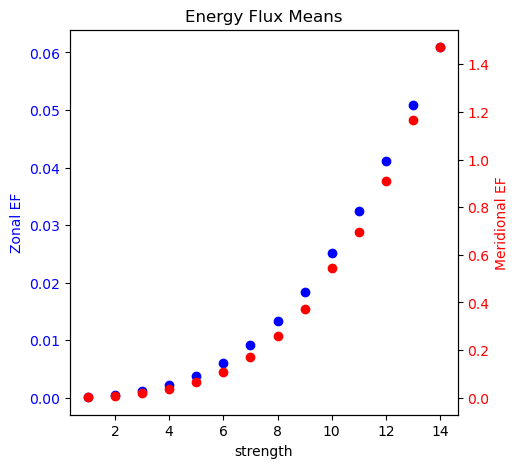

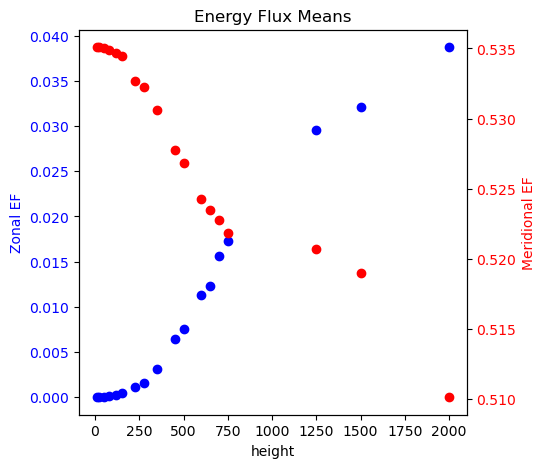

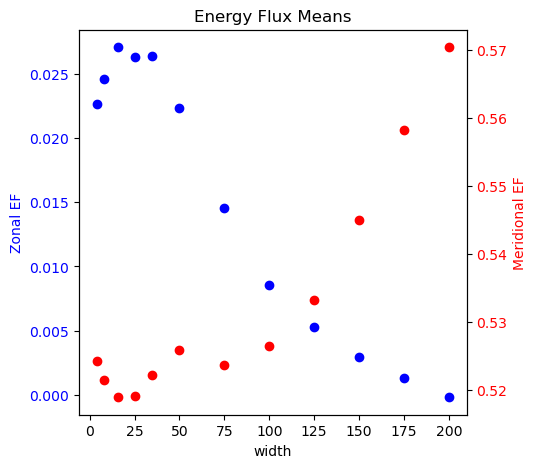

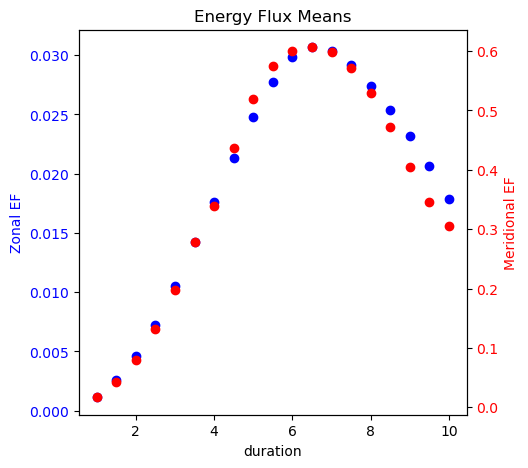

In [18]:
def ef_mean(data):
    u = data.u
    v = data.v
    pEast = data.pEast
    pNorth = data.pNorth
    endtime = int(u.time[-1].values)
    ztot = 4000 * 1000 * (u * pEast).sum("zl").integrate("time").integrate("yh").values
    mtot = 4000 * 1000 * (v * pNorth).sum("zl").integrate("time").integrate("xh").values


    zmean = ztot / (endtime * 500000 * 12500)
    mmean = mtot / (endtime * 500000 * 100000)
    return zmean,mmean


def plot_expt(expt,ax1):
    xax = []
    yax1 = []
    yax2 = []
    for run in data[expt]:
        xax.append(run)
        a,b = ef_mean(data[expt][run])
        yax1.append(a)
        yax2.append(b)

    xax,yax1,yax2 = np.array(xax),np.array(yax1),np.array(yax2)


    ax1.scatter(xax, yax1, color='blue')
    ax1.set_title('Energy Flux Means')
    ax1.set_xlabel(expt)
    ax1.set_ylabel('Zonal EF', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    ax2 = ax1.twinx()
    ax2.scatter(xax, yax2, color='red')
    ax2.set_ylabel('Meridional EF', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    return ax1



for i,expt in enumerate(["strength","height","width","duration"]):
    fig,ax = plt.subplots(1,figsize = (5,5))
    plot_expt(expt,ax)

    plt.show()


## Read everything in from scratch, and ensure that we're doing East and West as well as North and South boundaries!

In [40]:
def save_all_data(expt,run = "*"):
    """
    Same as in postprocess, but this time save all in one file for each expt. Also do East as well as west!!
    """
    if "forcing_width" not in expt:
        expt_base_name = expt.split("_")[0]
    else:
        expt_base_name = "forcing_width"
    levels = np.append(np.array([50,150]),np.full(19,200))

    basepath = Path("/home/149/ab8992/topographic-NIWs/rundirs") / expt_base_name / expt / "archive" / f"output{run}"
    print("basepath ",basepath)
    u = xr.open_mfdataset(str(basepath) + "/u.nc", decode_times = False,decode_cf = False).sel(yh = slice(-250,250)).sel(xq = [-250,250],method = "nearest").u.load()
    ufar = xr.open_mfdataset(str(basepath) + "/u.nc", decode_times = False,decode_cf = False).sel(yh = slice(-250,250)).isel(xq = 0).u.load()
    v = xr.open_mfdataset(str(basepath) + "/v.nc", decode_times = False,decode_cf = False).sel(xh = slice(-250,250)).sel(yq = [-250,250],method = "nearest").v.load()

    eEastFar = xr.open_mfdataset(str(basepath) + "/e.nc", decode_times = False,decode_cf = False).sel(yh = slice(-250,250)).isel(xh = 0).e.load()

    eEast = xr.open_mfdataset(str(basepath) + "/e.nc", decode_times = False,decode_cf = False).sel(yh = slice(-250,250)).sel(xh = 250,method = "nearest").e.load()
    eNorth = xr.open_mfdataset(str(basepath) + "/e.nc", decode_times = False,decode_cf = False).sel(xh = slice(-250,250)).sel(yh = 250,method = "nearest").e.load()
    eWest = xr.open_mfdataset(str(basepath) + "/e.nc", decode_times = False,decode_cf = False).sel(yh = slice(-250,250)).sel(xh = -250,method = "nearest").e.load()
    eSouth = xr.open_mfdataset(str(basepath) + "/e.nc", decode_times = False,decode_cf = False).sel(xh = slice(-250,250)).sel(yh = -250,method = "nearest").e.load()
    
    pEast = al.calculate_pressure(eEast,u.zl)
    pWest = al.calculate_pressure(eWest,u.zl)
    pEastFar = al.calculate_pressure(eEastFar,u.zl)
    pNorth = al.calculate_pressure(eNorth,u.zl)
    pSouth = al.calculate_pressure(eSouth,u.zl)

    pEast = pEast - pEast.isel(time = 0)
    pWest = pWest - pWest.isel(time = 0)
    pEastFar = pEastFar - pEastFar.isel(time = 0)
    pNorth = pNorth - pNorth.isel(time = 0)
    pSouth = pSouth - pSouth.isel(time = 0)

    out = xr.merge([u - ufar,
                    v,
                    (pEast - pEastFar).rename("pEast"),
                    pSouth.rename("pSouth"),
                    pNorth.rename("pNorth"),
                    (pWest - pEastFar).rename("pWest"),
                    ]).load()
    
    out.assign_coords(zl = levels)

    # Now integrate `out` to get the energy fluxes
    endtime = int(u.time[-1].values)

    ridge_width = 12500
    forcing_width = 100000
    if "forcing_width" in expt:
        forcing_width = float(expt.split("_")[-1])
    if "width" in expt:
        ridge_width = float(expt.split("_")[-1])


    EF_EW = 1000 * (
    (out.u.isel(xq = 1) * out.pEast - out.u.isel(xq = 0) * out.pWest) ## Sum the East and West energy fluxes
    .integrate("time")
    .integrate("yh")
    .integrate("zl")
    /  (endtime * 500000 * ridge_width)
    )

    EF_NS = 1000 * (
    (out.v.isel(yq = 1) * out.pNorth - out.v.isel(yq = 0) * out.pSouth) ## Sum the East and West energy fluxes
    .integrate("time")
    .integrate("xh")
    .integrate("zl")
    /  (endtime * 500000 * forcing_width)
    ) 

    outpath = Path("/g/data/v45/ab8992/postprocessed_bottomniws/") / expt_base_name / expt
    if not os.path.exists(outpath):
        os.makedirs(outpath)
    if run == "*":
        run = "all"
    xr.merge(
        [out,EF_EW.rename("EF_EW"),EF_NS.rename("EF_NS")]
        ).to_netcdf(outpath / f"{expt}_{run}.nc",mode = "w")
    print(f"Success {expt} {run}")
    return 

save_all_data("height_500")



basepath  /home/149/ab8992/topographic-NIWs/rundirs/height/height_500/archive/output*


PermissionError: [Errno 13] Permission denied: '/g/data/v45/ab8992/postprocessed_bottomniws/height/height_500/height_500_all.nc'

In [47]:
basepath = Path("/home/149/ab8992/topographic-NIWs/rundirs")
expt = "height"
for i in basepath.glob(expt +  "/*"):
    if expt in i.name:
        print(i.name)


height_10
height_20
height_50
height_80
height_120
height_150
height_225
height_275
height_350
height_450
height_500
height_600
height_650
height_700
height_750
height_1250
height_1500
height_2000


In [7]:
# def ef_mean(data):

    # return zmean,mmean

data = xr.open_dataset("/g/data/v45/ab8992/postprocessed_bottomniws/height/height_500/height_500_all.nc",
                       decode_times = False,decode_cf = False)



In [36]:
levels = np.append(np.array([50,150]),np.full(19,200))

endtime = int(data.u.time[-1].values)
ztot = 1000 * (
    (data.u.isel(xq = 1) * data.pEast - data.u.isel(xq = 0) * data.pWest) ## Sum the East and West energy fluxes
    .integrate("time")
    .integrate("yh")
    * levels
    ).sum("zl").values # Effectively integrate over z levels

#perform z integration

mtot = 1000 * (
    (data.v.isel(yq = 1) * data.pNorth - data.v.isel(yq = 0) * data.pSouth) ## Sum the North and South energy fluxes
    .integrate("time")
    .integrate("xh"))
    # * levels
    # ).sum("zl").values # Effectively integrate over z levels


zmean = ztot / (endtime * 500000 * 12500)
mmean = mtot / (endtime * 500000 * 100000)


print(zmean,mmean)


0.0005086704564696041 <xarray.DataArray (zl: 21)> Size: 168B
array([4.03324171e-05, 2.05228372e-05, 1.83507553e-05, 1.48124378e-05,
       1.10879600e-05, 8.34885609e-06, 7.18925692e-06, 7.35323723e-06,
       8.07039476e-06, 8.79836480e-06, 9.47765641e-06, 1.00464035e-05,
       1.01474524e-05, 9.52425170e-06, 8.44326966e-06, 7.54407120e-06,
       7.43938486e-06, 8.56113383e-06, 1.09178064e-05, 1.34690379e-05,
       1.50832519e-05])
Coordinates:
  * zl       (zl) float64 168B 1.019e+03 1.022e+03 ... 1.028e+03 1.028e+03


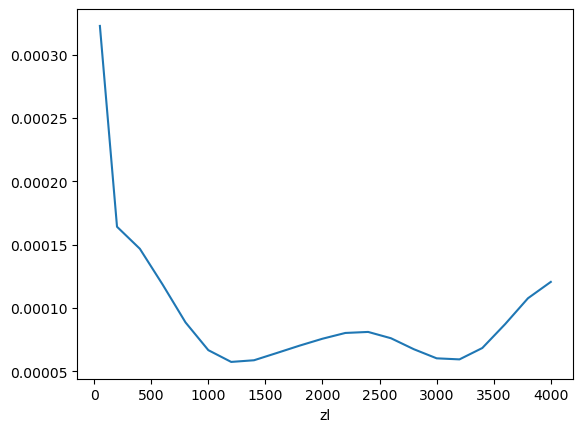

In [38]:
d = xr.DataArray(
    data = mtot.values / (endtime * 500000 * 12500),
    dims = "zl",
    coords = {"zl":np.cumsum(levels)}
)
d.plot()

In [39]:
print((d.integrate("zl")).values)
print((d.sum("zl") * 4000).values)

0.3523287930626806
8.176647581992983


In [16]:
levels
sum(levels)

4000